In [169]:
import pandas as pd
import numpy as np

In [170]:
df = pd.read_csv("Data/powerplant_data.csv")

In [171]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [172]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [173]:
X = df.drop(columns=["PE"], axis=1)
y = df["PE"]

In [174]:
from sklearn.model_selection import train_test_split

In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42,test_size=0.2
)

In [176]:
df.shape

(9568, 5)

In [177]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [178]:
from sklearn.decomposition import PCA

pca = PCA()

In [179]:
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [180]:
X_test_pca.shape

(1914, 4)

In [181]:
print("varience ratio : ", pca.explained_variance_ratio_)

varience ratio :  [0.61135177 0.22676621 0.13626814 0.02561388]


In [182]:
import torch
import torch.nn as nn

In [183]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [184]:
X_test_tensor = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

In [185]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [186]:
train_loader = DataLoader(train_dataset,batch_size=32)
test_loader = DataLoader(test_dataset,batch_size=32)

In [187]:
y_test_tensor.shape


torch.Size([1914, 1])

In [188]:
#Define ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train_pca.shape[1], 6),
            nn.ReLU(),

            #2nd hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #output layer
            nn.Linear(6, 1)
        )

    def forward(self, x) :
        return self.model(x)

In [189]:
import torch.optim as optim

model = ANN()

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [190]:
#Train ANN
train_losses = []
val_losses = []
epochs = 100

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        # xb = features of one batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) #forward prepogation..... predicted outputs fro this batch
        loss = crietrion(outputs, yb) # comoute loss
        loss.backward() # back prop... compute gradients
        optimizer.step()

        running_loss += loss.item() # loss is tensor -> py float
        
    epoch_train_loss =  running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ===> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

        if epoch_val_loss < best_val_loss :
            best_val_loss = epoch_val_loss

            torch.save(model.state_dict(),"best_model.pt")

epoch 1/100 ===> train loss = 205899.42994791668 & val loss = 203027.953125
epoch 2/100 ===> train loss = 193296.96614583334 & val loss = 177163.828125
epoch 3/100 ===> train loss = 149553.80169270834 & val loss = 117602.6484375
epoch 4/100 ===> train loss = 84606.17278645834 & val loss = 54801.875
epoch 5/100 ===> train loss = 34422.09088541667 & val loss = 20400.9140625
epoch 6/100 ===> train loss = 13371.60010172526 & val loss = 9638.8017578125
epoch 7/100 ===> train loss = 7426.279708862305 & val loss = 6246.3505859375
epoch 8/100 ===> train loss = 5222.597795613607 & val loss = 4571.9521484375
epoch 9/100 ===> train loss = 3975.4716990152997 & val loss = 3548.8427734375
epoch 10/100 ===> train loss = 3143.370964050293 & val loss = 2849.496337890625
epoch 11/100 ===> train loss = 2524.6632624308268 & val loss = 2309.16796875
epoch 12/100 ===> train loss = 2026.3148745218912 & val loss = 1862.4783935546875
epoch 13/100 ===> train loss = 1613.130892944336 & val loss = 1483.1427001953

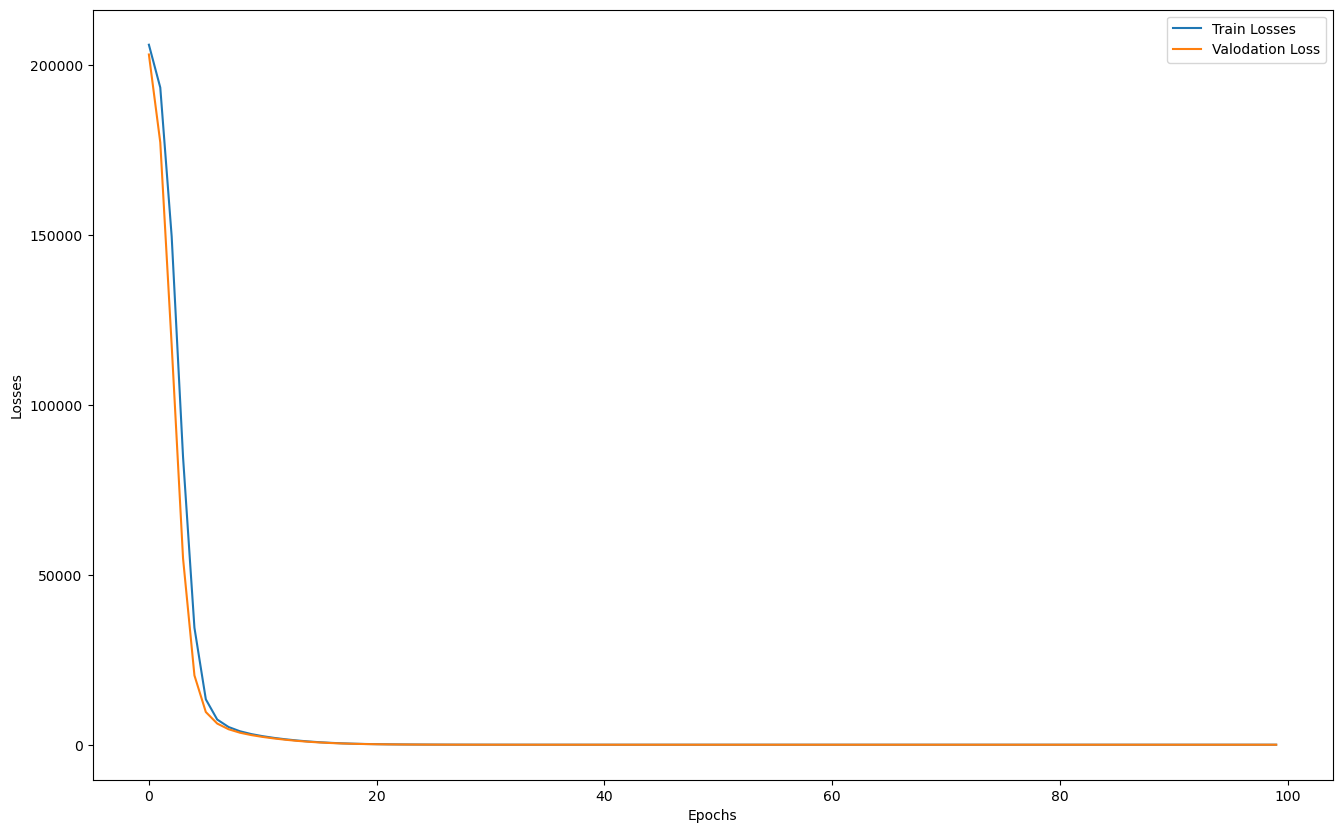

In [191]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Train Losses": train_losses,
    "Validation Losses" : val_losses
})

plt.figure(figsize=(16,10))

plt.plot(loss_df["Train Losses"], label = "Train Losses")
plt.plot(loss_df["Validation Losses"], label="Valodation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")


plt.legend()

In [192]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [193]:
# Evaluate model

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)


    train_mse_loss = crietrion(train_pred, y_train_tensor)
    test_mse_loss = crietrion(test_pred, y_test_tensor)

print("Train MSE:", train_mse_loss.item())
print("Test MSE:", test_mse_loss.item())

Train MSE: 21.37590980529785
Test MSE: 19.709054946899414


In [194]:
from sklearn.metrics import r2_score

print("r^2 score = ", r2_score(y_test, test_pred))

r^2 score =  0.9311219429966198


In [195]:
pred_df = pd.DataFrame(test_pred.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])

pd.concat([pred_df,actual_df], axis=1)

,Predicted Values,Actual Values
0,435.274323,433.27
1,437.325470,438.16
2,461.850433,458.42
3,476.574249,480.82
4,436.087341,441.41
...,...,...
1909,451.301910,456.70
1910,431.984406,438.04
1911,467.014038,467.80
1912,431.519135,437.14
